In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df = sns.load_dataset('iris')

In [23]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [24]:
# Label encode Species
from sklearn.preprocessing import LabelEncoder

In [25]:
encoder = LabelEncoder()

In [26]:
df['species'] = encoder.fit_transform(df['species'])

In [27]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


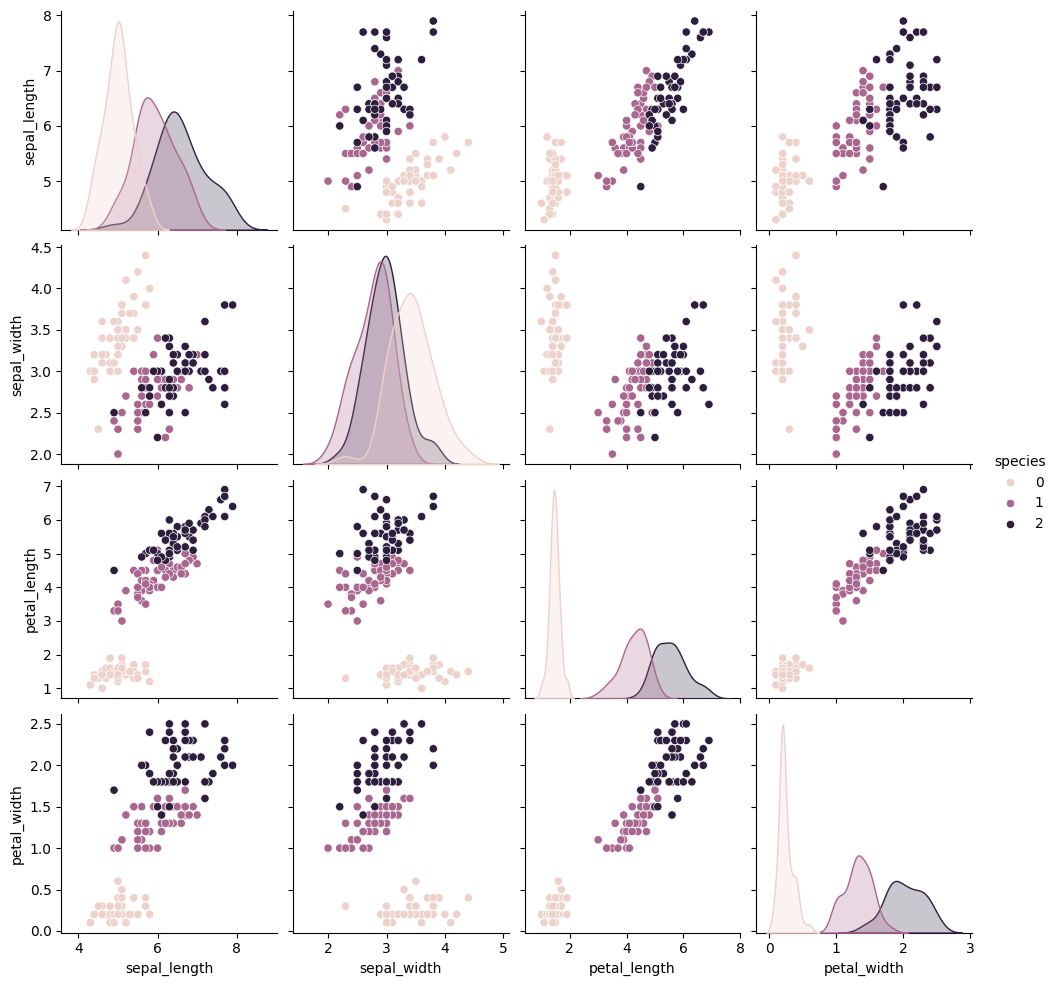

In [28]:
import seaborn as sns
sns.pairplot(df,hue='species')

In [29]:
new_df = df[df['species'] != 0][['sepal_length','sepal_width','species']]
new_df

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


In [30]:
new_df.shape

(100, 3)

In [31]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [33]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [34]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

In [35]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.73
knn 0.76


In [36]:
from sklearn.ensemble import VotingClassifier

## Hard Voting

In [37]:
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


## Soft Voting

In [38]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


## Weighted Voting

In [39]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))
            

for i=1,j=1,k=1 0.77
for i=1,j=1,k=2 0.77
for i=1,j=1,k=3 0.76
for i=1,j=2,k=1 0.76
for i=1,j=2,k=2 0.75
for i=1,j=2,k=3 0.76
for i=1,j=3,k=1 0.73
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.76
for i=2,j=1,k=1 0.78
for i=2,j=1,k=2 0.77
for i=2,j=1,k=3 0.77
for i=2,j=2,k=1 0.76
for i=2,j=2,k=2 0.77
for i=2,j=2,k=3 0.77
for i=2,j=3,k=1 0.74
for i=2,j=3,k=2 0.76
for i=2,j=3,k=3 0.75
for i=3,j=1,k=1 0.81
for i=3,j=1,k=2 0.79
for i=3,j=1,k=3 0.79
for i=3,j=2,k=1 0.77
for i=3,j=2,k=2 0.79
for i=3,j=2,k=3 0.76
for i=3,j=3,k=1 0.76
for i=3,j=3,k=2 0.76
for i=3,j=3,k=3 0.77


In [40]:
model_vc = VotingClassifier(estimators=estimators,voting='soft',weights=[3,1,1])
x = cross_val_score(
    estimator=model_vc,
    X=X,
    y=y,
    cv=10,
    scoring='accuracy'
)
print(np.round(np.mean(x),2))

0.8


## Classifiers of Same Algo

In [41]:
from sklearn.svm import SVC

In [42]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(kernel='poly', degree=1)
svm2 = SVC(kernel='poly', degree=2)
svm3 = SVC(kernel='poly', degree=3)
svm4 = SVC(kernel='poly', degree=4)
svm5 = SVC(kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


    5 same SVC model with different polynomial degree and if we choice any 1 out of 5 model we will choice SVM3 model bcz having highest accuarcy among all of them 
    But if we convert them into voting it may be better than SVM3

In [ ]:
# Try with hard voting 
vc = VotingClassifier(
    estimators=estimators,
    voting='hard'
)
score = cross_val_score(
    estimator=vc,
    X=X,
    y=y,
    cv=10,
    scoring='accuracy'
)

np.round(score.mean(),2)

np.float64(0.92)

In [46]:
# now try soft voting 
vc = VotingClassifier(
    estimators=estimators,
    voting='soft'
)
score = cross_val_score(
    estimator=vc,
    X=X,
    y=y,
    cv=10,
    scoring='accuracy'
)

np.round(score.mean(),2)

np.float64(0.93)

    SVC() actual SVM model banata hai, aur CalibratedClassifierCV() us SVM ko wrap karke calibrated probability
    predictions provide karta hai.

In [47]:
from sklearn.calibration import CalibratedClassifierCV

svm1 = CalibratedClassifierCV(SVC(kernel='poly', degree=1), ensemble=False)
svm2 = CalibratedClassifierCV(SVC(kernel='poly', degree=2), ensemble=False)
svm3 = CalibratedClassifierCV(SVC(kernel='poly', degree=3), ensemble=False)
svm4 = CalibratedClassifierCV(SVC(kernel='poly', degree=4), ensemble=False)
svm5 = CalibratedClassifierCV(SVC(kernel='poly', degree=5), ensemble=False)

In [48]:
estimators = [
    ('svm1', svm1),
    ('svm2', svm2),
    ('svm3', svm3),
    ('svm4', svm4),
    ('svm5', svm5)
]

vc1 = VotingClassifier(
    estimators=estimators,
    voting='soft'
)

x = cross_val_score(
    vc1,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print(np.round(np.mean(x), 2))

0.93
